In [2]:
import ast

s = '''
match x:
    case Point.Var(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    Match(
      subject=Name(id='x', ctx=Load()),
      cases=[
        match_case(
          pattern=MatchClass(
            cls=Attribute(
              value=Name(id='Point', ctx=Load()),
              attr='Var',
              ctx=Load()),
            patterns=[
              MatchClass(
                cls=Name(id='P', ctx=Load())),
              MatchValue(
                value=Constant(value='y'))]),
          body=[
            Pass()])])])


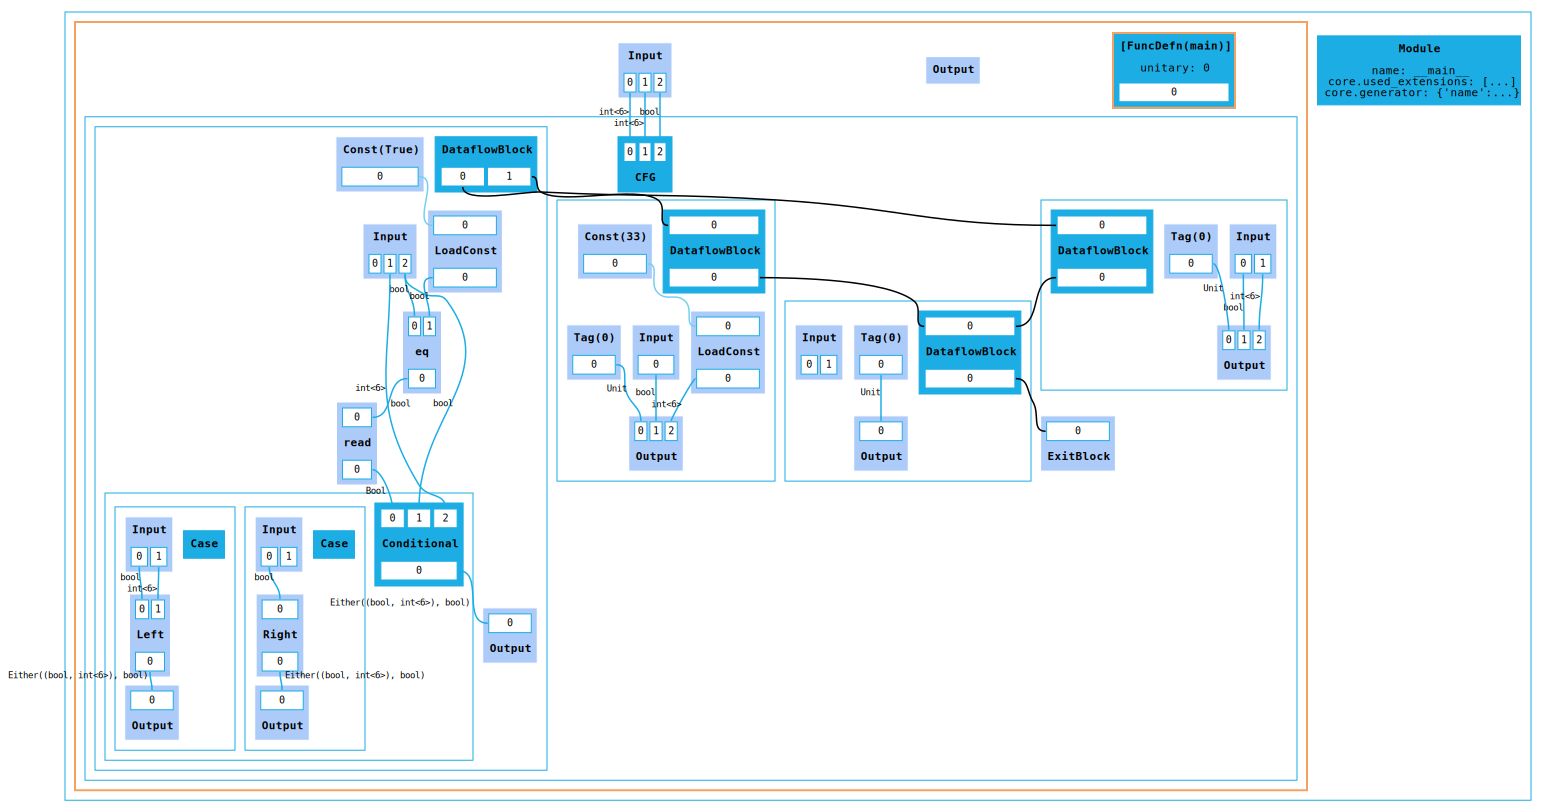

In [3]:
from guppylang import guppy
from guppylang.std.quantum import qubit, h, measure, x
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int


@guppy
def main(a: int, q: int, c : bool) -> None:

    if c == True:
        q = 33
    else:
        pass

    a = q
    d = c
    
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=1000))

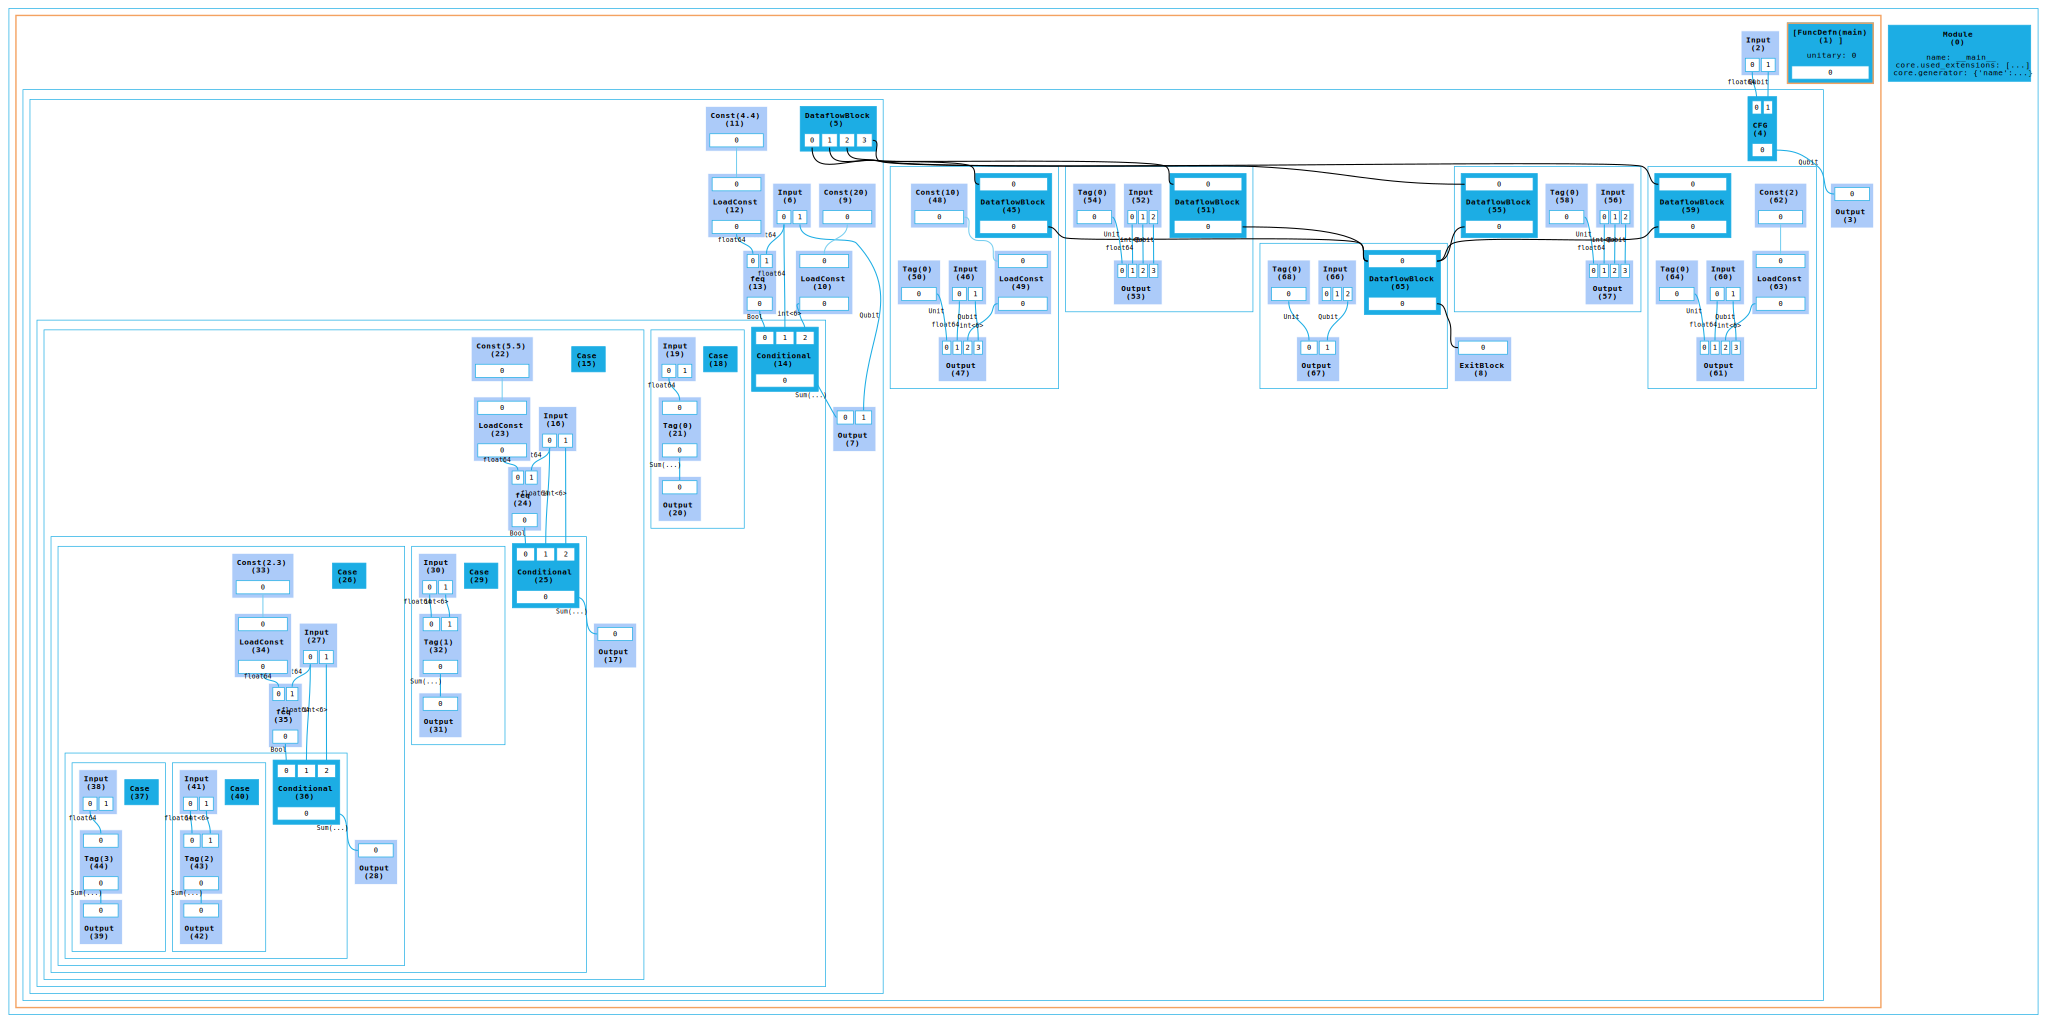

In [4]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned
from selene_hugr_qis_compiler import check_hugr
from hugr.hugr.render import RenderConfig

@guppy
def fun() -> int:
    return 42

@guppy
def main(a:float, q: qubit) -> None:
    x = 20
    match a:
        case 4.4:
            x = 10
        case 5.5:
            pass
        case 2.3:
            pass
        case _:
            x = 2


    b = x
    c = a


hu = main.compile_function().modules[0]
# with open("hugr_output.dot", "w") as f:
#     f.write(str(hu.render_dot(config=RenderConfig(max_edge_label_length=100, display_node_id=True))))
check_hugr(hu.to_bytes())
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100, display_node_id=True))


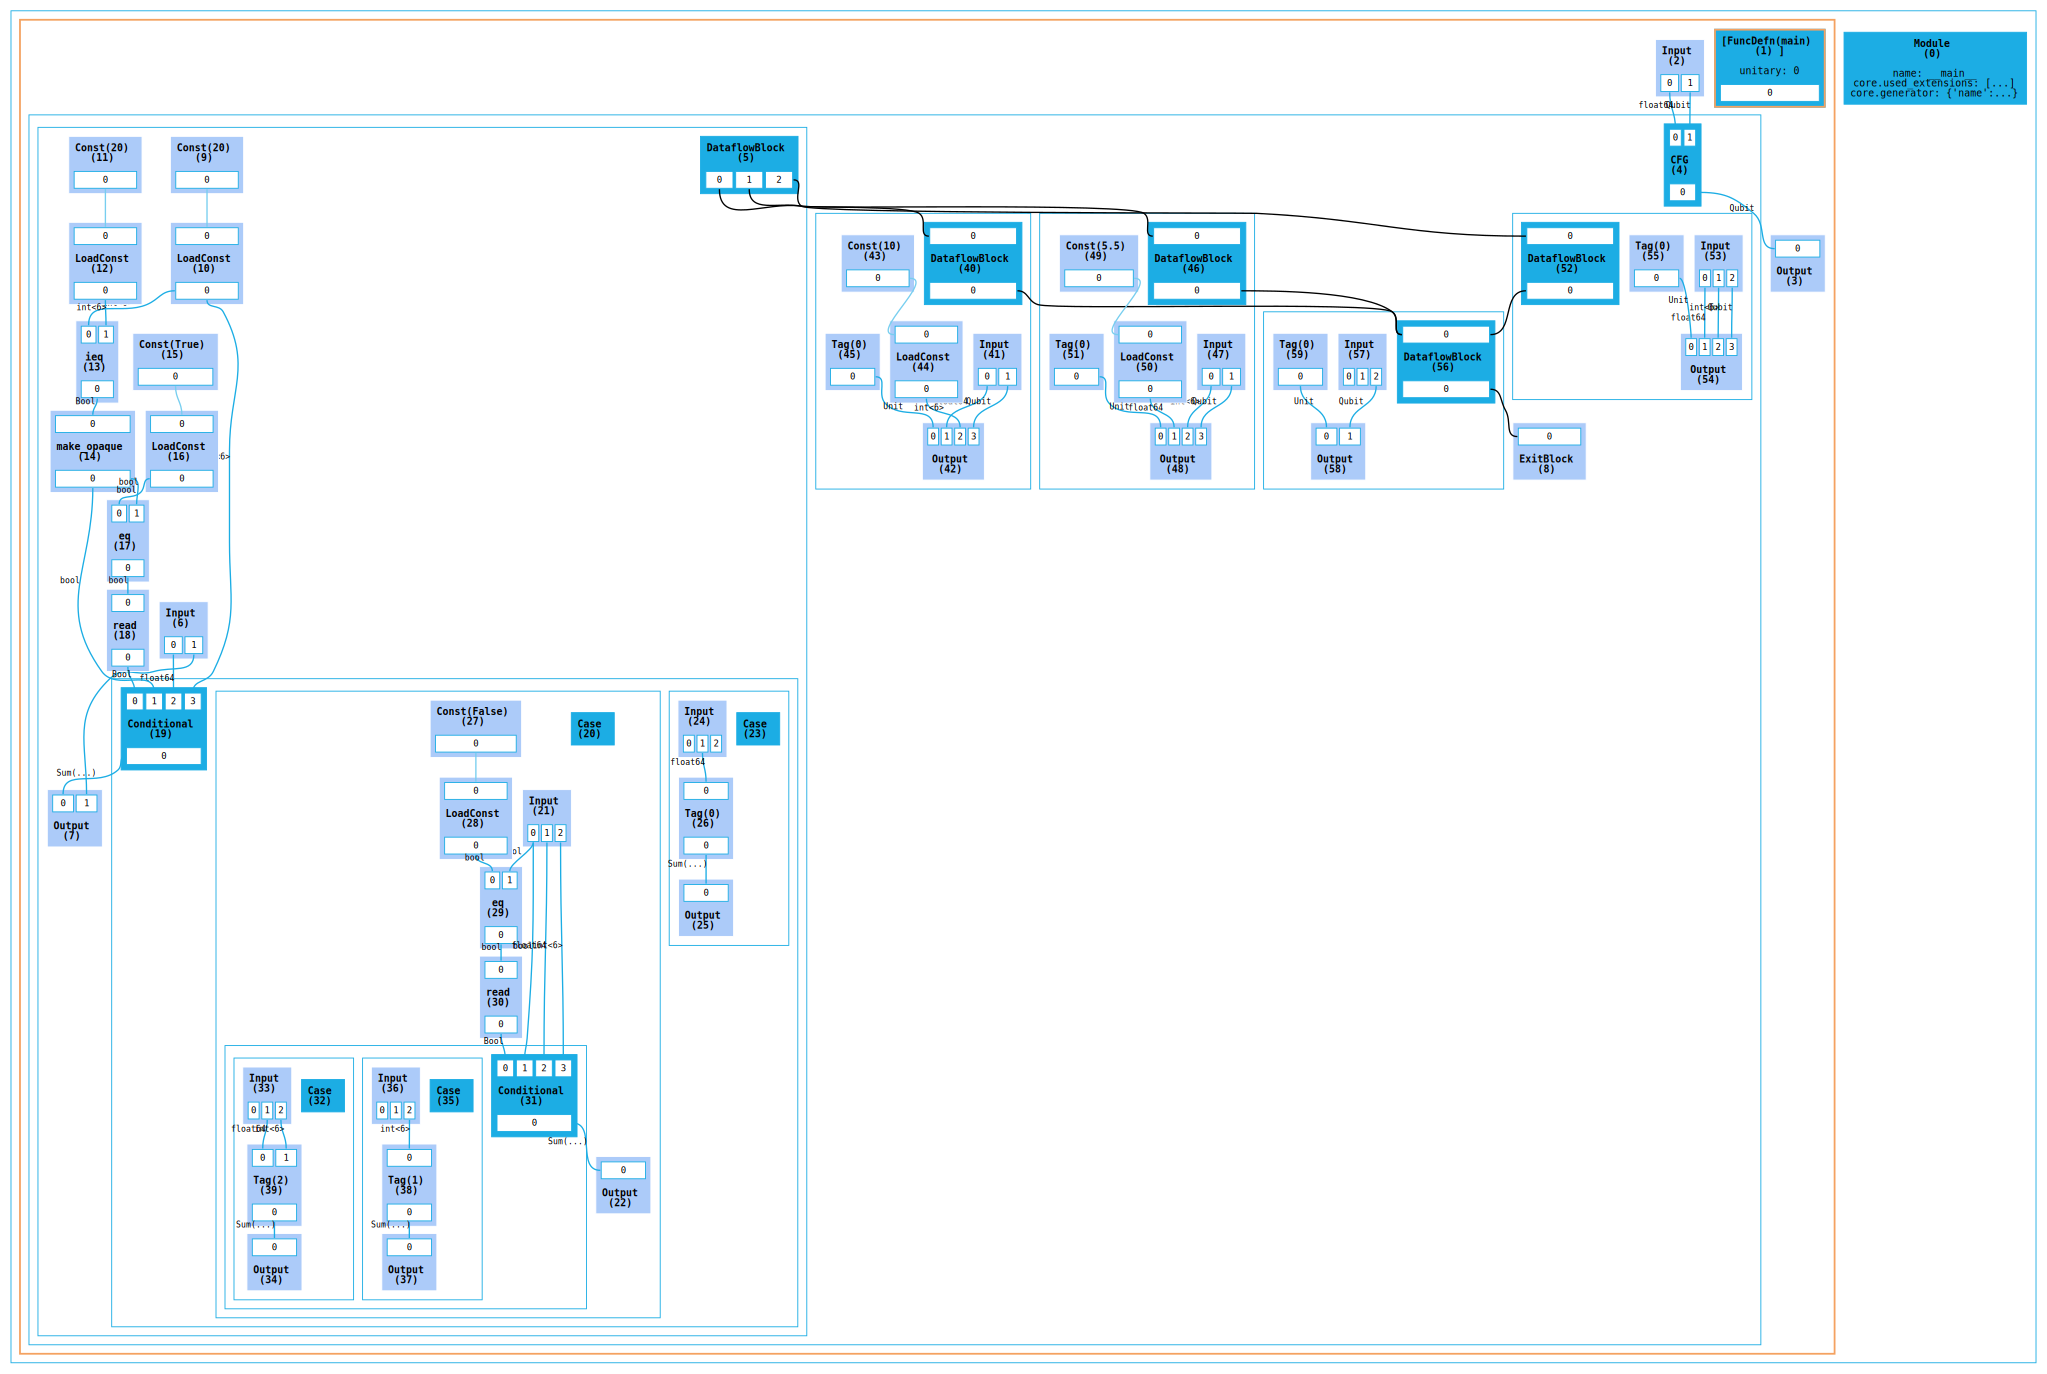

In [2]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned
from selene_hugr_qis_compiler import check_hugr
from hugr.hugr.render import RenderConfig

@guppy
def fun() -> int:
    return 42

@guppy
def main(a:float, q: qubit) -> None:
    x = 20
    match x == 20:
        case True:
            x = 10
        case False:
            a = 5.5
        

    b = x
    c = a


hu = main.compile_function().modules[0]
# with open("hugr_output.dot", "w") as f:
#     f.write(str(hu.render_dot(config=RenderConfig(max_edge_label_length=100, display_node_id=True))))
check_hugr(hu.to_bytes())
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100, display_node_id=True))
